# 4. Problema A: predicción de `PAY_AMT4`

### 4.1 Data leakage

Se aborda un problema de regresión cuyo objetivo es predecir la variable `PAY_AMT4` correspondiente al monto de pago realizado por el cliente en junio de 2005 (según los datos).

Dado que el dataset contiene información temporal desde abril hasta septiembre de 2005, es importante evitar **data leakage**, es decir, el uso de información futura respecto al momento de predicción. En este contexto, utilizar variables de meses posteriores a junio podría inflar artificialmente el desempeño del modelo, ya que incorporaría señales que no estarían disponibles en un escenario real.

Por esta razón, para predecir `PAY_AMT4` se utilizarán únicamente variables demográficas y variables financieras históricas previas al mes de junio:

Variables PERMITIDAS:
- Demográficas: `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`.
- Estado de pago: `PAY_5`, `PAY_6`.
- Monto de factura: `BILL_AMT5`, `BILL_AMT6`.
- Monto de pago previo: `PAY_AMT5`, `PAY_AMT6`.

Variables EXCLUIDAS por leakage:
- `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`..
- `BILL_AMT1`, `BILL_AMT2`, `BILL_AMT3`, `BILL_AMT4`.
- `PAY_AMT1`, `PAY_AMT2`, `PAY_AMT3`.
- `default.payment.next.month`.

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Emiliano\Desktop\BLUEPRUEBA\default_limpio.csv")

# Variables permitidas.
features = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
            "PAY_5", "PAY_6",
            "BILL_AMT5", "BILL_AMT6",
            "PAY_AMT5", "PAY_AMT6"]

target = "PAY_AMT4"

X = df[features]
y = df[target]

print("Features utilizadas:", features)
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Features utilizadas: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_5', 'PAY_6', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT5', 'PAY_AMT6']
Shape X: (30000, 11)
Shape y: (30000,)


### 4.2 EDA Específica (PAY_AMT4)

Distribución y correlación

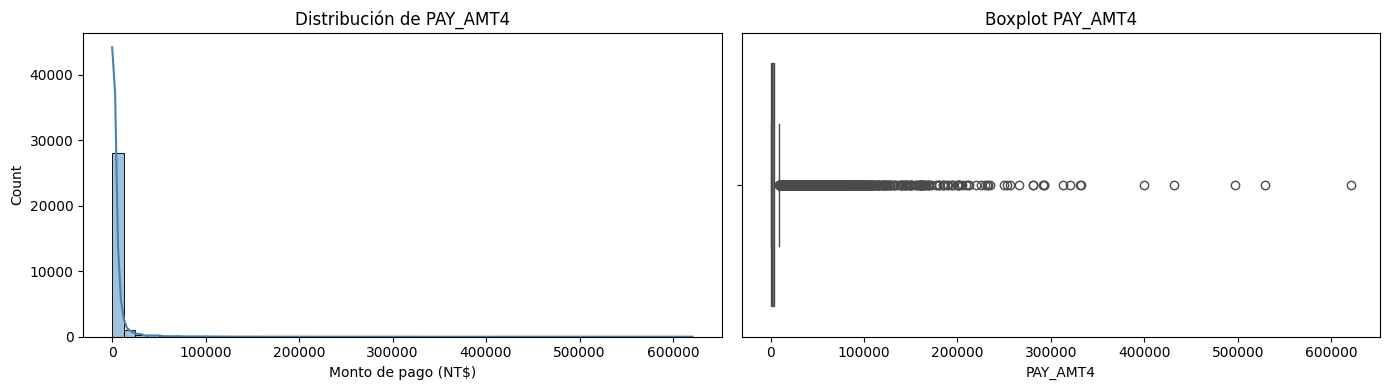

Media: 4826.08
Mediana: 1500.0
Máximo: 621000
% de clientes que no pagaron nada: 21.36 %


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(y, bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de PAY_AMT4")
axes[0].set_xlabel("Monto de pago (NT$)")

sns.boxplot(x=y, ax=axes[1], color="steelblue")
axes[1].set_title("Boxplot PAY_AMT4")

plt.tight_layout()
plt.show()

print("Media:", y.mean().round(2))
print("Mediana:", y.median())
print("Máximo:", y.max())
print("% de clientes que no pagaron nada:", (y == 0).mean().round(4) * 100, "%")

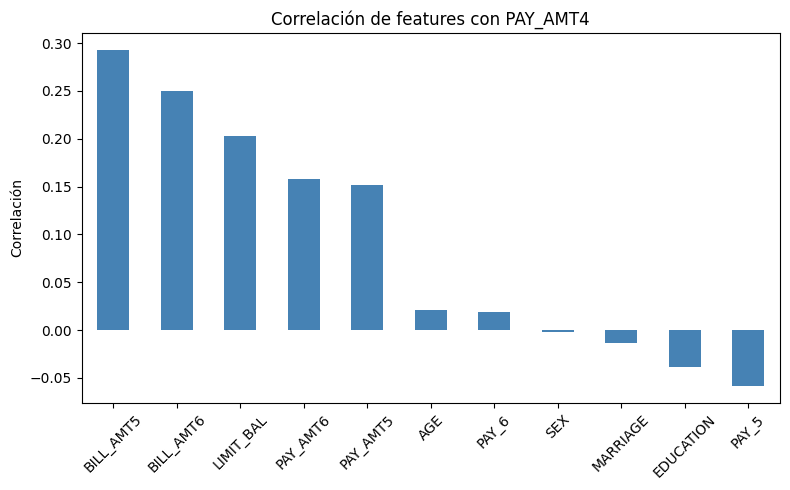

BILL_AMT5    0.293118
BILL_AMT6    0.250237
LIMIT_BAL    0.203242
PAY_AMT6     0.157834
PAY_AMT5     0.151830
AGE          0.021379
PAY_6        0.019018
SEX         -0.002229
MARRIAGE    -0.013440
EDUCATION   -0.038353
PAY_5       -0.058299
Name: PAY_AMT4, dtype: float64


In [4]:
correlaciones = df[features + [target]].corr()[target].drop(target).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
correlaciones.plot(kind="bar", color="steelblue")
plt.title("Correlación de features con PAY_AMT4")
plt.ylabel("Correlación")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(correlaciones)

### 4.3 Feature Engineering

Se crearon nuevas variables basadas en el comportamiento financiero histórico del cliente,  únicamente se utilizo información previa a junio de 2005.

In [6]:
df["BILL_AMT_PROM"] = df[["BILL_AMT5", "BILL_AMT6"]].mean(axis=1)   # Promedio de facturas previas (abril y mayo).


df["PAY_AMT_PROM"] = df[["PAY_AMT5", "PAY_AMT6"]].mean(axis=1)   # Promedio de pagos previos.


df["RATIO_PAGO_MAY"] = df["PAY_AMT5"] / (df["BILL_AMT5"] + 1)   # Ratio pago/factura en mayo (qué tanto pagó respecto a lo que debía).


df["RATIO_PAGO_ABR"] = df["PAY_AMT6"] / (df["BILL_AMT6"] + 1)   # Ratio pago/factura en abril..

features = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
            "PAY_5", "PAY_6",
            "BILL_AMT5", "BILL_AMT6",
            "PAY_AMT5", "PAY_AMT6",
            "BILL_AMT_PROM", "PAY_AMT_PROM",
            "RATIO_PAGO_MAY", "RATIO_PAGO_ABR"]

X = df[features]
y = df[target]

print("Features totales:", len(features))
print(features)

Features totales: 15
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_5', 'PAY_6', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT5', 'PAY_AMT6', 'BILL_AMT_PROM', 'PAY_AMT_PROM', 'RATIO_PAGO_MAY', 'RATIO_PAGO_ABR']


### 4.4 Modelos

Para el problema de regresión se comparan dos enfoques; en primer lugar, se utiliza regresión lineal como modelo base, garcias a su  simplicidad e interpretabilidad. 
En segundo lugar, se entrena un modelo XGBoost, capaz de capturar relaciones no lineales y patrones más complejos en los datos. 

Esta comparación permite evaluar si un modelo más flexible aporta mejoras sustanciales respecto a una alternativa lineal más sencilla.

── Regresión Lineal ──
R²:         0.1544
RMSE:       11765.81
MAE:        4811.05
R² CV mean: 0.1569 (+/- 0.0143)

── XGBoost ──
R²:         0.5979
RMSE:       8113.48
MAE:        2205.25
R² CV mean: 0.6086 (+/- 0.0421)

Comparación de modelos:
             Modelo        R2          RMSE          MAE
0  Regresión Lineal  0.154397  11765.812101  4811.045977
1           XGBoost  0.597897   8113.483346  2205.250000


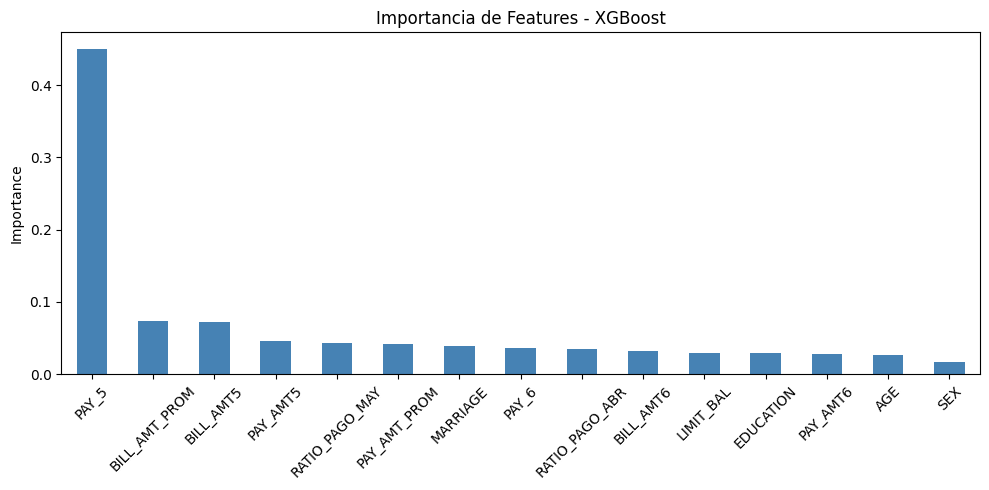

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline  # ← faltaba este import
from xgboost import XGBRegressor
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)  #reemplazar inf por NaN para que SimpleImputer pueda manejarlos.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODELO 1: Regresión Lineal
lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)          # ← fit al pipeline
y_pred_lr = lr_pipeline.predict(X_test)    # ← predict al pipeline

r2_lr   = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
cv_scores_lr = cross_val_score(lr_pipeline, X_train, y_train, cv=5, scoring="r2")  # ← pipeline

print("── Regresión Lineal ──")
print(f"R²:         {r2_lr:.4f}")
print(f"RMSE:       {rmse_lr:.2f}")
print(f"MAE:        {mae_lr:.2f}")
print(f"R² CV mean: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# MODELO 2: XGBoost (maneja NaN nativamente)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

r2_xgb   = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring="r2")

print("\n── XGBoost ──")
print(f"R²:         {r2_xgb:.4f}")
print(f"RMSE:       {rmse_xgb:.2f}")
print(f"MAE:        {mae_xgb:.2f}")
print(f"R² CV mean: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

# Tabla comparativa
results = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "XGBoost"],
    "R2":   [r2_lr,   r2_xgb],
    "RMSE": [rmse_lr, rmse_xgb],
    "MAE":  [mae_lr,  mae_xgb]
})
print("\nComparación de modelos:")
print(results)

# Feature importance XGBoost
feat_imp = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar", color="steelblue")
plt.title("Importancia de Features - XGBoost")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### 4.5 Selección del Mejor Modelo

Se selecciona **XGBoost** como el mejor modelo para predecir `PAY_AMT4` por las siguientes razones:

- R² superior: XGBoost obtuvo 0.5979 vs 0.1544 de la Regresión Lineal, explicando casi 4 veces más varianza en los datos.
- Menor error: RMSE de 8,113 NT$ vs 11,765 NT$ y MAE de 2,205 NT$ vs 4,811 NT$, lo que representa errores significativamente menores en términos absolutos.
- Consistencia: El R² en cross-validation (0.6086 +/- 0.0421) es muy cercano al obtenido en test, lo que indica que el modelo generaliza bien y no hay overfitting.
- Captura no linealidad: La distribución de `PAY_AMT4` es altamente sesgada con muchos valores en cero, lo cual un modelo lineal no puede capturar bien. 
XGBoost maneja este tipo de distribuciones de forma natural.

Por lo tanto la Regresión Lineal se conserva como baseline de comparación, pero no es adecuada para este problema dado el comportamiento no lineal de la variable objetivo.